# LINEAR vs MLP REGRESSION EXPERIMENT (PyTorch)

## Overview

This script implements a complete end-to-end regression experiment using PyTorch. The goal is to compare the performance of different model classes on a supervised learning task and evaluate their ability to generalize.

We train and evaluate three models:

- **Linear Regression**: a simple baseline model representing a linear relationship.
- **MLP (Multi-Layer Perceptron)**: a non-linear neural network capable of learning complex functions.
- **Regularized MLP (AdamW)**: an MLP trained with weight decay to reduce overfitting.

---

## Pipeline Summary

The workflow follows a standard machine learning pipeline:

1. **Data Loading**
   - Reads train/test CSV datasets.
   - Splits training data into train and validation sets.

2. **Preprocessing**
   - Computes Z-score normalization statistics from training data only.
   - Applies normalization to inputs and targets.

3. **Dataset Construction**
   - Wraps data into a custom PyTorch `Dataset`.
   - Enables batched loading via `DataLoader`.

4. **Model Training**
   - Uses MSE loss as the optimization objective.
   - Trains with Adam / AdamW optimizers.
   - Supports early stopping for selected models.

5. **Evaluation**
   - Tracks training and validation loss over time.
   - Evaluates final performance using RMSE and MAE in original (denormalized) space.

6. **Model Selection**
   - Selects the best model based on validation RMSE.

7. **Final Testing**
   - Evaluates the selected model on a held-out test set.
   - Generates continuous prediction curves for visualization.

---

## Key Design Principles

- **Reproducibility**: fixed random seeds across NumPy and PyTorch.
- **No data leakage**: normalization statistics computed only on training data.
- **Separation of concerns**: clear distinction between data, model, training, and evaluation.
- **Comparative evaluation**: multiple architectures trained under identical conditions.

---

## Output

The script produces:
- Training and validation loss curves (log scale)
- Model comparison plots
- Final test metrics (RMSE, MAE)
- Prediction visualizations across the input domain


# IMPORTS


### Dependencies and Environment Setup
Loads the core library ecosystem:
*   `torch` and its utilities for building the neural networks and handling mini-batches.
*   `numpy` and `pandas` for processing data matrices.
*   `matplotlib` for evaluating and diagnostic plotting of model behavior.
*   `sklearn` for clean dataset partitioning.

In [1]:
from pathlib import Path
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split


# REPRODUCIBILITY

### Global Determinism Configuration

Freezes pseudo-random number generator seeds across Python, NumPy, and PyTorch. 

This eliminates stochastic variance between runs, guaranteeing identical, debuggable results every time the script executes.


In [2]:
def set_seed(seed=42):

    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Extra reproducibility for CUDA
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [3]:
set_seed(42)


# DEVICE

### Hardware Allocation

Checks for available CUDA-capable GPUs to offload tensor computations. 

If no GPU is present, it defaults to the CPU.


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")


Using device: cpu


# PATHS

###  File System Constants

Uses `pathlib.Path` to establish clear, platform-agnostic directory structures pointing to the raw dataset resources.


In [5]:
DATA_DIR = Path("data/regression")


# NORMALIZATION HELPERS

### Mathematical Scaling Utilities

Implements standard Z-score normalization functions. 

`normalize` converts raw values into a standard distribution ($\mu=0, \sigma=1$) to keep gradients stable. 

`denormalize` reverts scaled model outputs back to original units.


In [6]:
def normalize(x, mean, std):
    return (x - mean) / std


def denormalize(x, mean, std):
    return (x * std) + mean


# DATASET CLASS

### Custom PyTorch Dataset Wrapper
Inherits from `torch.utils.data.Dataset`. 

It encapsulates raw feature arrays, applies Z-score normalization safely within the object initialization, and handles tensor conversion.


In [7]:
class RegressionDataset(Dataset):
    def __init__(
        self,
        df,
        normalize_x=False,
        normalize_y=False,
        x_mean=None,
        x_std=None,
        y_mean=None,
        y_std=None
    ):

        self.raw_x = df["x"].values.astype(np.float32).reshape(-1, 1)
        self.raw_y = df["y"].values.astype(np.float32).reshape(-1, 1)
        x = self.raw_x.copy()
        y = self.raw_y.copy()

        # Normalize inputs
        if normalize_x:
            if x_mean is None or x_std is None:
                raise ValueError("x_mean and x_std must be provided when normalize_x=True")
            x = normalize(x, x_mean, x_std)

        # Normalize targets

        if normalize_y:
            if y_mean is None or y_std is None:
                raise ValueError("y_mean and y_std must be provided when normalize_y=True")
            y = normalize(y, y_mean, y_std)

        self.x_mean = x_mean
        self.x_std = x_std
        
        self.y_mean = y_mean
        self.y_std = y_std

        self.x = torch.tensor(x, dtype=torch.float32)

        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]


# LOAD & SPLIT DATA

### Data Partitioning

Reads raw data files and splits the initial training file into two subsets:
- **Train (75%)** for gradient updates, and 
- **Validation (25%)** for monitoring generalization.


In [8]:
train_full_df = pd.read_csv(DATA_DIR / "train" / "dataset.csv")

test_df = pd.read_csv(DATA_DIR / "test" / "dataset.csv")

train_df, val_df = train_test_split(
    train_full_df,
    test_size=0.25,
    random_state=42
)

print(f"\nTrain split size:      {len(train_df)}")
print(f"Validation split size: {len(val_df)}")
print(f"Test size:             {len(test_df)}")



Train split size:      300
Validation split size: 100
Test size:             180


# COMPUTE NORMALIZATION STATISTICS

### Statistical Calculations (Preventing Data Leakage)

Computes the mean ($\mu$) and population standard deviation ($\sigma$) strictly from the **training split alone**. 

An explicit epsilon (`EPS`) prevents division-by-zero errors.

> **IMPORTANT**: Statistics MUST be computed ONLY on the training split.
 `ddof=0` computes the population standard deviation.


In [9]:
EPS = 1e-8

x_mean = train_df["x"].mean()
x_std = train_df["x"].std(ddof=0) + EPS

y_mean = train_df["y"].mean()
y_std = train_df["y"].std(ddof=0) + EPS

print(f"\nTrain x mean: {x_mean:.4f}")
print(f"Train x std:  {x_std:.4f}")

print(f"\nTrain y mean: {y_mean:.4f}")
print(f"Train y std:  {y_std:.4f}")



Train x mean: -0.0371
Train x std:  0.5754

Train y mean: 0.1093
Train y std:  1.1883


# CREATE DATASETS

### Dataset Initialization
Instantiates the structural datasets. 

Training split statistics are passed down to scale validation and test pipelines uniformly.

> Neural networks usually train more stably when both inputs and targets are approximately centered and scaled.


In [10]:
train_dataset = RegressionDataset(
    train_df,
    normalize_x=True,
    normalize_y=True,
    x_mean=x_mean,
    x_std=x_std,
    y_mean=y_mean,
    y_std=y_std
)

val_dataset = RegressionDataset(
    val_df,
    normalize_x=True,
    normalize_y=True,
    x_mean=x_mean,
    x_std=x_std,
    y_mean=y_mean,
    y_std=y_std
)

test_dataset = RegressionDataset(
    test_df,
    normalize_x=True,
    normalize_y=True,
    x_mean=x_mean,
    x_std=x_std,
    y_mean=y_mean,
    y_std=y_std
)


# DATALOADERS

### Mini-batch Generators

Wraps our sequential datasets into iterative PyTorch `DataLoaders`. 

Shuffling is enabled for the training loader to break cyclic data bias.


In [11]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)


# TRAINING FUNCTIONS

### Optimization and Evaluation Engines

Defines training, validation, and optimization lifecycles. 

Tracks the optimal training epoch configuration and preserves the best state weights dictionary.


In [12]:
def train_epoch(model, loader, loss_fn, optimizer):
    model.train()
    total_loss = 0
    dataset_size = 0
    for xb, yb in loader:
        dataset_size += xb.size(0)
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = loss_fn(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        
    return total_loss / dataset_size


In [13]:
def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss = 0
    dataset_size = 0
    with torch.no_grad():
        for xb, yb in loader:
            dataset_size += xb.size(0)
            xb = xb.to(device)
            yb = yb.to(device)
            preds = model(xb)
            loss = loss_fn(preds, yb)
            total_loss += loss.item() * xb.size(0)
            
    return total_loss / dataset_size


In [14]:
def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    loss_fn,
    max_epochs,
    patience
):

    model = model.to(device)
    train_losses = []
    val_losses = []
    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0

    for epoch in range(max_epochs):
        
        train_loss = train_epoch(model, train_loader, loss_fn, optimizer)
        val_loss = evaluate(model, val_loader, loss_fn)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # Save best model
        if patience and val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        # Print progress
        if epoch % 25 == 0:
            print(f"Epoch {epoch:4d} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

        # Early stopping
        if patience and patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch}")
            break

        # Save final state if no early stopping is used
        if epoch == max_epochs - 1:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return train_losses, val_losses, best_val_loss


# MODELS

### Model Architecture Definitions

Defines candidate neural network configurations using standard PyTorch object modules: 

*   `LinearRegression`: Low capacity single layer baseline setup.
*   `MLP`: Deep multi-layer perceptron mapping non-linear combinations via stacked linear layers and ReLU activations.

> ReLU introduces piecewise linear regions, allowing function approximation beyond global linearity


In [15]:
class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)


In [16]:
class MLP(nn.Module):
    def __init__(self, hidden_size=32):
        super().__init__()
        self.hidden_size = hidden_size
        self.fc1 = nn.Linear(1, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x


In [17]:
# Create models
lin = LinearRegression()
mlp = MLP(hidden_size=16)
reg_mlp = MLP(hidden_size=512)


# PARAMETER COUNTING

### Capacity Analysis

Calculates total learnable variables across network candidates to numerically evaluate architectural complexity and risks of capacity overfitting.


In [18]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


In [19]:
print(f"\nLinear Regression params: {count_parameters(lin)}")
print(f"MLP params: {count_parameters(mlp)}")
print(f"Regularized MLP params: {count_parameters(reg_mlp)}")



Linear Regression params: 2
MLP params: 321
Regularized MLP params: 264193


# TRAIN MODELS

### Training Loop Implementations

Configures individual loss criterion objectives and learning optimizer algorithms across the baseline models, logging empirical progression across the training timeline.


**We introduce Regularization via Early Stopping and AdamW**. 

This does not change model capacity, only how weights are allowed to grow during optimization.


>AdamW applies weight decay directly to parameters instead of through the loss, decoupling regularization from Adam’s adaptive gradient scaling and resulting in more consistent regularization behavior.


In [20]:
criterion = nn.MSELoss()

lr = 1e-3

opt_lin = torch.optim.Adam(lin.parameters(), lr=lr)

opt_mlp = torch.optim.Adam(mlp.parameters(), lr=lr)

opt_reg_mlp = torch.optim.AdamW(reg_mlp.parameters(), lr=lr, weight_decay=1e-3)


In [21]:
print("\nTRAINING LINEAR MODEL")
lin_train_losses, lin_val_losses, lin_best_val_loss = train_model(lin, 
                                                                  train_loader, val_loader, 
                                                                  opt_lin, criterion,
                                                                  max_epochs=20000,patience=0)

print("\nTRAINING MLP")
mlp_train_losses, mlp_val_losses, mlp_best_val_loss = train_model(mlp, 
                                                                  train_loader, val_loader, 
                                                                  opt_mlp, criterion,
                                                                  max_epochs=20000,patience=0)

print("\nTRAINING REGULARIZED MLP")
reg_train_losses, reg_val_losses, reg_best_val_loss = train_model(reg_mlp,
                                                                  train_loader, val_loader,
                                                                  opt_reg_mlp, criterion,
                                                                  max_epochs=20000,patience=500)



TRAINING LINEAR MODEL
Epoch    0 | Train Loss: 3.453045 | Val Loss: 3.184649
Epoch   25 | Train Loss: 2.908509 | Val Loss: 2.680799
Epoch   50 | Train Loss: 2.449920 | Val Loss: 2.257519
Epoch   75 | Train Loss: 2.062960 | Val Loss: 1.902827
Epoch  100 | Train Loss: 1.738541 | Val Loss: 1.607403
Epoch  125 | Train Loss: 1.469874 | Val Loss: 1.364441
Epoch  150 | Train Loss: 1.247711 | Val Loss: 1.164873
Epoch  175 | Train Loss: 1.067185 | Val Loss: 1.003404
Epoch  200 | Train Loss: 0.919988 | Val Loss: 0.872598
Epoch  225 | Train Loss: 0.801473 | Val Loss: 0.767413
Epoch  250 | Train Loss: 0.706205 | Val Loss: 0.682963
Epoch  275 | Train Loss: 0.630274 | Val Loss: 0.615690
Epoch  300 | Train Loss: 0.570501 | Val Loss: 0.562812
Epoch  325 | Train Loss: 0.523680 | Val Loss: 0.520931
Epoch  350 | Train Loss: 0.488053 | Val Loss: 0.489059
Epoch  375 | Train Loss: 0.460864 | Val Loss: 0.464696
Epoch  400 | Train Loss: 0.440767 | Val Loss: 0.446821
Epoch  425 | Train Loss: 0.426249 | Val Lo

Epoch 3725 | Train Loss: 0.396379 | Val Loss: 0.406691
Epoch 3750 | Train Loss: 0.396361 | Val Loss: 0.407363
Epoch 3775 | Train Loss: 0.396392 | Val Loss: 0.408029
Epoch 3800 | Train Loss: 0.396357 | Val Loss: 0.407088
Epoch 3825 | Train Loss: 0.396373 | Val Loss: 0.407523
Epoch 3850 | Train Loss: 0.396358 | Val Loss: 0.407245
Epoch 3875 | Train Loss: 0.396375 | Val Loss: 0.407287
Epoch 3900 | Train Loss: 0.396357 | Val Loss: 0.407327
Epoch 3925 | Train Loss: 0.396352 | Val Loss: 0.407091
Epoch 3950 | Train Loss: 0.396383 | Val Loss: 0.407126
Epoch 3975 | Train Loss: 0.396360 | Val Loss: 0.407735
Epoch 4000 | Train Loss: 0.396363 | Val Loss: 0.407718
Epoch 4025 | Train Loss: 0.396366 | Val Loss: 0.407191
Epoch 4050 | Train Loss: 0.396343 | Val Loss: 0.407377
Epoch 4075 | Train Loss: 0.396353 | Val Loss: 0.407125
Epoch 4100 | Train Loss: 0.396366 | Val Loss: 0.407201
Epoch 4125 | Train Loss: 0.396361 | Val Loss: 0.407764
Epoch 4150 | Train Loss: 0.396368 | Val Loss: 0.407275
Epoch 4175

Epoch 7475 | Train Loss: 0.396363 | Val Loss: 0.407567
Epoch 7500 | Train Loss: 0.396355 | Val Loss: 0.407457
Epoch 7525 | Train Loss: 0.396391 | Val Loss: 0.407118
Epoch 7550 | Train Loss: 0.396357 | Val Loss: 0.407605
Epoch 7575 | Train Loss: 0.396388 | Val Loss: 0.407621
Epoch 7600 | Train Loss: 0.396356 | Val Loss: 0.407981
Epoch 7625 | Train Loss: 0.396366 | Val Loss: 0.407048
Epoch 7650 | Train Loss: 0.396346 | Val Loss: 0.407427
Epoch 7675 | Train Loss: 0.396395 | Val Loss: 0.407577
Epoch 7700 | Train Loss: 0.396367 | Val Loss: 0.407384
Epoch 7725 | Train Loss: 0.396350 | Val Loss: 0.407506
Epoch 7750 | Train Loss: 0.396371 | Val Loss: 0.407190
Epoch 7775 | Train Loss: 0.396402 | Val Loss: 0.407948
Epoch 7800 | Train Loss: 0.396381 | Val Loss: 0.407254
Epoch 7825 | Train Loss: 0.396362 | Val Loss: 0.407471
Epoch 7850 | Train Loss: 0.396369 | Val Loss: 0.407618
Epoch 7875 | Train Loss: 0.396345 | Val Loss: 0.407367
Epoch 7900 | Train Loss: 0.396365 | Val Loss: 0.407382
Epoch 7925

Epoch 11225 | Train Loss: 0.396356 | Val Loss: 0.407002
Epoch 11250 | Train Loss: 0.396360 | Val Loss: 0.407150
Epoch 11275 | Train Loss: 0.396414 | Val Loss: 0.407568
Epoch 11300 | Train Loss: 0.396381 | Val Loss: 0.407229
Epoch 11325 | Train Loss: 0.396366 | Val Loss: 0.407041
Epoch 11350 | Train Loss: 0.396347 | Val Loss: 0.407702
Epoch 11375 | Train Loss: 0.396358 | Val Loss: 0.407267
Epoch 11400 | Train Loss: 0.396353 | Val Loss: 0.407404
Epoch 11425 | Train Loss: 0.396350 | Val Loss: 0.407153
Epoch 11450 | Train Loss: 0.396355 | Val Loss: 0.407504
Epoch 11475 | Train Loss: 0.396347 | Val Loss: 0.407320
Epoch 11500 | Train Loss: 0.396370 | Val Loss: 0.407689
Epoch 11525 | Train Loss: 0.396385 | Val Loss: 0.408048
Epoch 11550 | Train Loss: 0.396381 | Val Loss: 0.407809
Epoch 11575 | Train Loss: 0.396363 | Val Loss: 0.407120
Epoch 11600 | Train Loss: 0.396375 | Val Loss: 0.407003
Epoch 11625 | Train Loss: 0.396356 | Val Loss: 0.407345
Epoch 11650 | Train Loss: 0.396345 | Val Loss: 0

Epoch 14975 | Train Loss: 0.396352 | Val Loss: 0.407231
Epoch 15000 | Train Loss: 0.396365 | Val Loss: 0.407417
Epoch 15025 | Train Loss: 0.396357 | Val Loss: 0.407243
Epoch 15050 | Train Loss: 0.396361 | Val Loss: 0.407269
Epoch 15075 | Train Loss: 0.396399 | Val Loss: 0.407290
Epoch 15100 | Train Loss: 0.396355 | Val Loss: 0.407474
Epoch 15125 | Train Loss: 0.396398 | Val Loss: 0.407562
Epoch 15150 | Train Loss: 0.396352 | Val Loss: 0.407511
Epoch 15175 | Train Loss: 0.396342 | Val Loss: 0.407596
Epoch 15200 | Train Loss: 0.396366 | Val Loss: 0.407450
Epoch 15225 | Train Loss: 0.396414 | Val Loss: 0.407464
Epoch 15250 | Train Loss: 0.396363 | Val Loss: 0.407680
Epoch 15275 | Train Loss: 0.396367 | Val Loss: 0.406869
Epoch 15300 | Train Loss: 0.396349 | Val Loss: 0.407260
Epoch 15325 | Train Loss: 0.396351 | Val Loss: 0.407103
Epoch 15350 | Train Loss: 0.396391 | Val Loss: 0.407197
Epoch 15375 | Train Loss: 0.396418 | Val Loss: 0.406991
Epoch 15400 | Train Loss: 0.396379 | Val Loss: 0

...

Epoch 6225 | Train Loss: 0.077600 | Val Loss: 0.098579
Epoch 6250 | Train Loss: 0.076453 | Val Loss: 0.097296
Epoch 6275 | Train Loss: 0.076644 | Val Loss: 0.096838
Epoch 6300 | Train Loss: 0.076297 | Val Loss: 0.098544
Epoch 6325 | Train Loss: 0.076368 | Val Loss: 0.096391
Epoch 6350 | Train Loss: 0.077118 | Val Loss: 0.096645
Epoch 6375 | Train Loss: 0.075939 | Val Loss: 0.096806
Epoch 6400 | Train Loss: 0.076365 | Val Loss: 0.097879
Epoch 6425 | Train Loss: 0.075783 | Val Loss: 0.097436
Epoch 6450 | Train Loss: 0.077092 | Val Loss: 0.096218
Epoch 6475 | Train Loss: 0.076112 | Val Loss: 0.096428
Epoch 6500 | Train Loss: 0.077155 | Val Loss: 0.095049
Epoch 6525 | Train Loss: 0.076383 | Val Loss: 0.095329
Epoch 6550 | Train Loss: 0.076120 | Val Loss: 0.095999
Epoch 6575 | Train Loss: 0.075722 | Val Loss: 0.097334
Epoch 6600 | Train Loss: 0.075822 | Val Loss: 0.096258
Epoch 6625 | Train Loss: 0.075859 | Val Loss: 0.095921
Epoch 6650 | Train Loss: 0.076802 | Val Loss: 0.096722
Epoch 6675

Epoch 9975 | Train Loss: 0.073707 | Val Loss: 0.090935
Epoch 10000 | Train Loss: 0.073491 | Val Loss: 0.093323
Epoch 10025 | Train Loss: 0.073424 | Val Loss: 0.091987
Epoch 10050 | Train Loss: 0.073130 | Val Loss: 0.092108
Epoch 10075 | Train Loss: 0.074316 | Val Loss: 0.094151
Epoch 10100 | Train Loss: 0.073807 | Val Loss: 0.091682
Epoch 10125 | Train Loss: 0.073969 | Val Loss: 0.094382
Epoch 10150 | Train Loss: 0.073421 | Val Loss: 0.091513
Epoch 10175 | Train Loss: 0.073190 | Val Loss: 0.091702
Epoch 10200 | Train Loss: 0.073187 | Val Loss: 0.092448
Epoch 10225 | Train Loss: 0.073215 | Val Loss: 0.092419
Epoch 10250 | Train Loss: 0.074256 | Val Loss: 0.091465
Epoch 10275 | Train Loss: 0.073723 | Val Loss: 0.092857
Epoch 10300 | Train Loss: 0.074565 | Val Loss: 0.092395
Epoch 10325 | Train Loss: 0.073265 | Val Loss: 0.091851
Epoch 10350 | Train Loss: 0.074883 | Val Loss: 0.091506
Epoch 10375 | Train Loss: 0.074312 | Val Loss: 0.091316
Epoch 10400 | Train Loss: 0.073856 | Val Loss: 0.

Epoch 13725 | Train Loss: 0.073489 | Val Loss: 0.089795
Epoch 13750 | Train Loss: 0.072326 | Val Loss: 0.089894
Epoch 13775 | Train Loss: 0.073373 | Val Loss: 0.089461
Epoch 13800 | Train Loss: 0.072477 | Val Loss: 0.091381
Epoch 13825 | Train Loss: 0.072535 | Val Loss: 0.091745
Epoch 13850 | Train Loss: 0.073191 | Val Loss: 0.090073
Epoch 13875 | Train Loss: 0.072322 | Val Loss: 0.090406
Epoch 13900 | Train Loss: 0.073894 | Val Loss: 0.090424
Epoch 13925 | Train Loss: 0.072397 | Val Loss: 0.090854
Epoch 13950 | Train Loss: 0.072447 | Val Loss: 0.089711
Epoch 13975 | Train Loss: 0.073711 | Val Loss: 0.090193
Epoch 14000 | Train Loss: 0.073391 | Val Loss: 0.090219
Epoch 14025 | Train Loss: 0.072175 | Val Loss: 0.089968
Epoch 14050 | Train Loss: 0.072328 | Val Loss: 0.091116
Epoch 14075 | Train Loss: 0.072643 | Val Loss: 0.090962
Epoch 14100 | Train Loss: 0.072563 | Val Loss: 0.090975
Epoch 14125 | Train Loss: 0.072344 | Val Loss: 0.089930
Epoch 14150 | Train Loss: 0.072314 | Val Loss: 0

Epoch 17475 | Train Loss: 0.072011 | Val Loss: 0.091309
Epoch 17500 | Train Loss: 0.072689 | Val Loss: 0.089973
Epoch 17525 | Train Loss: 0.071648 | Val Loss: 0.089901
Epoch 17550 | Train Loss: 0.072581 | Val Loss: 0.091141
Epoch 17575 | Train Loss: 0.072354 | Val Loss: 0.091426
Epoch 17600 | Train Loss: 0.071750 | Val Loss: 0.090136
Epoch 17625 | Train Loss: 0.072688 | Val Loss: 0.090642
Epoch 17650 | Train Loss: 0.074763 | Val Loss: 0.091183
Epoch 17675 | Train Loss: 0.072883 | Val Loss: 0.090003
Epoch 17700 | Train Loss: 0.071972 | Val Loss: 0.089416
Epoch 17725 | Train Loss: 0.072033 | Val Loss: 0.089182
Epoch 17750 | Train Loss: 0.071856 | Val Loss: 0.090560
Epoch 17775 | Train Loss: 0.071527 | Val Loss: 0.090742
Epoch 17800 | Train Loss: 0.072829 | Val Loss: 0.088730
Epoch 17825 | Train Loss: 0.071971 | Val Loss: 0.089918
Epoch 17850 | Train Loss: 0.071948 | Val Loss: 0.092816
Epoch 17875 | Train Loss: 0.071729 | Val Loss: 0.089756
Epoch 17900 | Train Loss: 0.072468 | Val Loss: 0

Epoch 1150 | Train Loss: 0.070075 | Val Loss: 0.094754
Epoch 1175 | Train Loss: 0.068857 | Val Loss: 0.093496
Epoch 1200 | Train Loss: 0.072380 | Val Loss: 0.103787
Epoch 1225 | Train Loss: 0.086420 | Val Loss: 0.123520
Epoch 1250 | Train Loss: 0.074199 | Val Loss: 0.092876
Epoch 1275 | Train Loss: 0.074413 | Val Loss: 0.097074
Epoch 1300 | Train Loss: 0.069627 | Val Loss: 0.093012
Epoch 1325 | Train Loss: 0.077663 | Val Loss: 0.090841
Epoch 1350 | Train Loss: 0.070812 | Val Loss: 0.092731
Epoch 1375 | Train Loss: 0.069715 | Val Loss: 0.090663
Epoch 1400 | Train Loss: 0.072685 | Val Loss: 0.092476
Epoch 1425 | Train Loss: 0.073302 | Val Loss: 0.094961

Early stopping at epoch 1425


# LEARNING CURVES

### Loss Curve Diagnostics

Generates comparative visual traces monitoring progress over train and validation optimization horizons using standard logarithmic scaling.


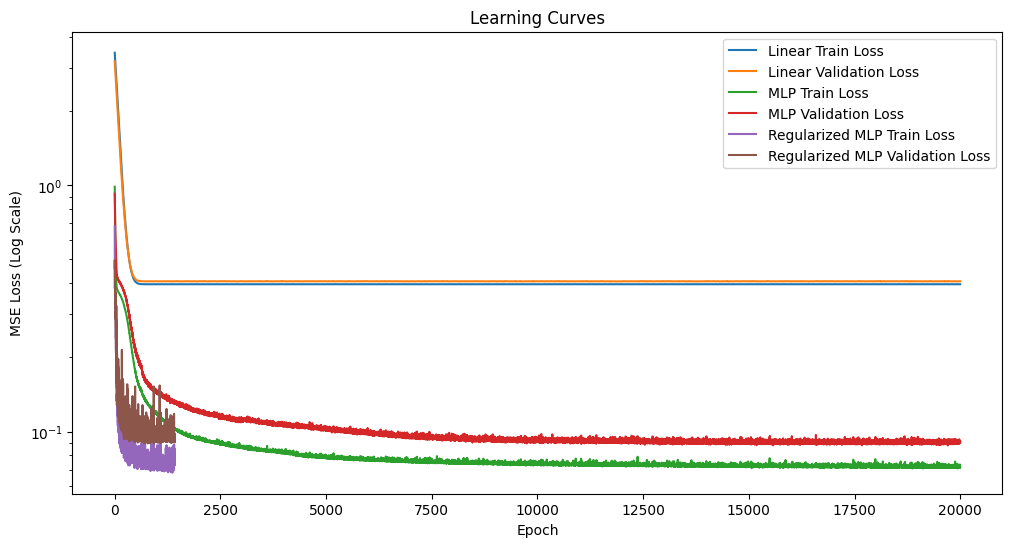

In [22]:
plt.figure(figsize=(12, 6))
# Linear model
plt.plot(lin_train_losses, label="Linear Train Loss")
plt.plot(lin_val_losses, label="Linear Validation Loss")
# MLP
plt.plot(mlp_train_losses, label="MLP Train Loss")
plt.plot(mlp_val_losses, label="MLP Validation Loss")
# Regularized MLP
plt.plot(reg_train_losses, label="Regularized MLP Train Loss")
plt.plot(reg_val_losses, label="Regularized MLP Validation Loss")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (Log Scale)")
plt.title("Learning Curves")
plt.legend()
plt.show()


# PREDICTION FUNCTION

### Safe Inference Pipeline
Encapsulates all necessary deployment transformations on incoming unscaled numpy array evaluations, mapping predictions cleanly back to original units.



In [23]:
def predict(model, x_numpy, x_mean, x_std, y_mean, y_std):
    dev = next(model.parameters()).device
    model.eval()
    # Normalize inputs
    x_numpy = normalize(x_numpy, x_mean, x_std)
    x_tensor = torch.tensor(x_numpy, dtype=torch.float32, device=dev)

    with torch.no_grad():
        preds = model(x_tensor)

    preds = preds.cpu().numpy()

    # Denormalize outputs
    preds = denormalize(preds, y_mean, y_std)

    return preds


# GENERATE PREDICTIONS

### Continuous Domain Sampling

Samples structural predictions along an evenly spaced geometric layout grid mapping the structural capabilities of all baseline models.


In [24]:
x_plot = np.linspace(-1, 1, 400).reshape(-1, 1).astype(np.float32)

lin_preds = predict(lin, x_plot, x_mean, x_std, y_mean, y_std)

mlp_preds = predict(mlp, x_plot, x_mean, x_std, y_mean, y_std)

reg_preds = predict(reg_mlp, x_plot, x_mean, x_std, y_mean, y_std)


# REAL-WORLD EVALUATION

### Denormalized Performance Profiling

Maps targets back onto unscaled dimensions to evaluate structural deviations in original domain units using MAE and RMSE metrics.



In [25]:
def evaluate_real_world(model, loader, y_mean, y_std):
    dev = next(model.parameters()).device
    model.eval()

    total_mse = 0
    total_mae = 0
    dataset_size = 0

    with torch.no_grad():
        for xb, yb in loader:
            
            dataset_size += xb.size(0)
            
            xb = xb.to(dev)
            yb = yb.to(dev)
            preds = model(xb)
            # Denormalize predictions and targets
            preds_real = denormalize(preds, y_mean, y_std)

            yb_real = denormalize(yb, y_mean, y_std)

            batch_mse = nn.functional.mse_loss(preds_real, yb_real, reduction="sum")
            batch_mae = nn.functional.l1_loss(preds_real,  yb_real, reduction="sum")

            total_mse += batch_mse.item()
            total_mae += batch_mae.item()

    final_mse = total_mse / dataset_size
    final_rmse = np.sqrt(final_mse)
    final_mae = total_mae / dataset_size
    
    return final_rmse, final_mae


# MODEL PERFORMANCE

### Validation Performance Scoring

Aggregates performance trackers across baseline networks to evaluate unscaled generalization performance metrics on the validation dataset split.

> **Test set is untouched until final evaluation**

In [26]:
models = {
    "Linear Model": lin,
    "MLP": mlp,
    "Regularized MLP": reg_mlp
}

metrics = {}


In [27]:
print("PERFORMANCE ON TRAIN SET")

for model_name, model in models.items():

    train_rmse, train_mae = evaluate_real_world(
        model,
        train_loader,
        y_mean,
        y_std
    )

    metrics[model_name] = {"train_rmse": train_rmse, "train_mae": train_mae}

    print(f"\n{model_name}")
    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Train MAE : {train_mae:.4f}")


PERFORMANCE ON TRAIN SET

Linear Model
Train RMSE: 0.7481
Train MAE : 0.6321

MLP
Train RMSE: 0.3171
Train MAE : 0.2482

Regularized MLP
Train RMSE: 0.3153
Train MAE : 0.2505


In [28]:
print("PERFORMANCE ON VALIDATION SET")

for model_name, model in models.items():

    val_rmse, val_mae = evaluate_real_world(
        model,
        val_loader,
        y_mean,
        y_std
    )

    metrics[model_name]["val_rmse"] = val_rmse
    metrics[model_name]["val_mae"] = val_mae

    print(f"\n{model_name}")
    print(f"Validation RMSE: {val_rmse:.4f}")
    print(f"Validation MAE : {val_mae:.4f}")


PERFORMANCE ON VALIDATION SET

Linear Model
Validation RMSE: 0.7582
Validation MAE : 0.6557

MLP
Validation RMSE: 0.3586
Validation MAE : 0.2903

Regularized MLP
Validation RMSE: 0.3553
Validation MAE : 0.2855


# VISUALIZATION — MODEL COMPARISON

### Multi-Panel Performance Mapping

Generates a side-by-side subplot view comparing model tracking curves directly against raw underlying data coordinates.

> **Test set is untouched until final evaluation**

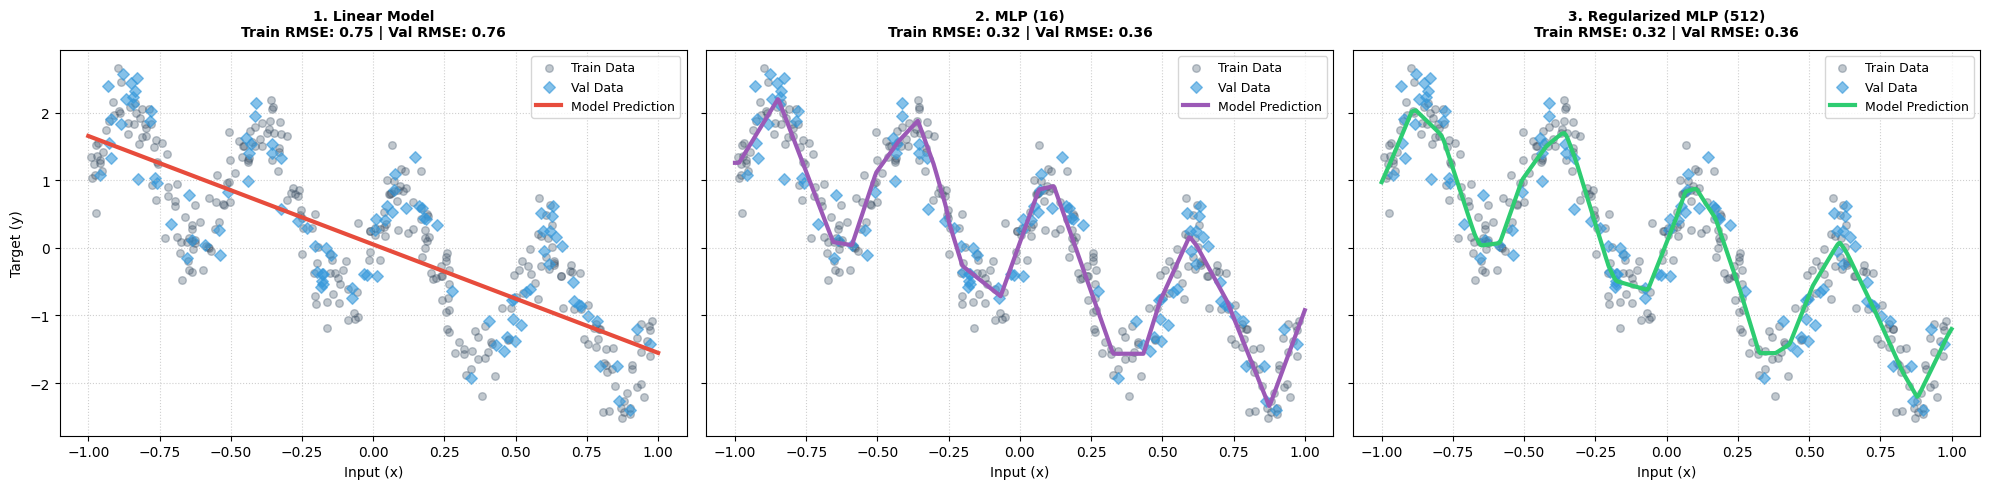

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

titles = [
    f"1. Linear Model\n"
    f"Train RMSE: {metrics['Linear Model']['train_rmse']:.2f} | "
    f"Val RMSE: {metrics['Linear Model']['val_rmse']:.2f}",

    f"2. MLP ({mlp.hidden_size})\n"
    f"Train RMSE: {metrics['MLP']['train_rmse']:.2f} | "
    f"Val RMSE: {metrics['MLP']['val_rmse']:.2f}",

    f"3. Regularized MLP ({reg_mlp.hidden_size})\n"
    f"Train RMSE: {metrics['Regularized MLP']['train_rmse']:.2f} | "
    f"Val RMSE: {metrics['Regularized MLP']['val_rmse']:.2f}"
]

predictions = [lin_preds, mlp_preds, reg_preds ]

colors = ['#e74c3c', '#9b59b6', '#2ecc71']

for i, ax in enumerate(axes):
    
    # Train data
    ax.scatter(train_df["x"], train_df["y"], color='#34495e', alpha=0.3, s=30, label='Train Data')
    
    # Validation data
    ax.scatter(val_df["x"], val_df["y"], color='#3498db', marker='D', alpha=0.6, s=35, label='Val Data')

    # Model predictions
    ax.plot(x_plot, predictions[i], color=colors[i], linewidth=3, label='Model Prediction')

    # Styling
    ax.set_title(titles[i], fontsize=10, fontweight='bold', pad=10)
    ax.set_xlabel('Input (x)')
    ax.grid(True, linestyle=':', alpha=0.6)

    if i == 0:
        ax.set_ylabel('Target (y)')

    ax.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.show()


# MODEL SELECTION ON VALIDATION SET

### Automated Architecture Selection

Identifies the best-performing neural configuration by picking the architecture that yields the minimum unscaled Validation RMSE.

> We select model using validation RMSE stored in metrics

**The improvement is not due to a different architecture, but due to constrained parameter growth leading to smoother functions.**

In [30]:
best_model_name = min(
    metrics,
    key=lambda model_name: metrics[model_name]["val_rmse"]
)

best_model = models[best_model_name]

print("MODEL SELECTION")
print(f"Selected model: {best_model_name}")
print(f"Validation RMSE: {metrics[best_model_name]['val_rmse']:.4f}")


MODEL SELECTION
Selected model: Regularized MLP
Validation RMSE: 0.3553


# FINAL EVALUATION ON TEST SET

### Unbiased Performance Check

Evaluates the finalized retrained model structure against isolated testing partitions to establish realistic real-world inference metrics.


In [31]:
test_rmse, test_mae = evaluate_real_world(best_model, test_loader, y_mean, y_std)

print("FINAL TEST PERFORMANCE")
print(f"Selected model: {best_model_name}")
print(f"Test RMSE: {test_rmse:.4f} (Penalizes large errors more strongly)")
print(f"Test MAE:  {test_mae:.4f} (Average absolute prediction error)")


FINAL TEST PERFORMANCE
Selected model: Regularized MLP
Test RMSE: 0.3798 (Penalizes large errors more strongly)
Test MAE:  0.3024 (Average absolute prediction error)


# GENERATE TEST PREDICTIONS

### Test Curve Inference Sampling
Passes continuous evaluation grid configurations through our selected, retrained network pipeline.

> Use the shared prediction utility function to avoid duplicated normalization/device logic.


In [32]:
test_predictions = predict(best_model, x_plot, x_mean, x_std, y_mean, y_std)


# VISUALIZATION — BEST MODEL ON TEST SET

### Final Verification Curve Plotting

Maps the finalized prediction function trace across all partitioned data coordinates simultaneously, establishing crisp visual proof of generalization.


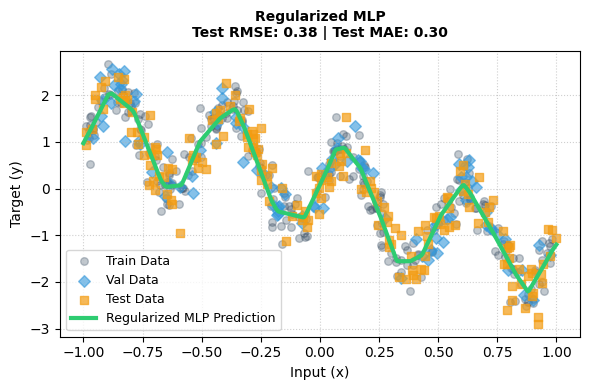

In [33]:
plt.figure(figsize=(6, 4))

# Train data
plt.scatter(train_df["x"], train_df["y"], color='#34495e', alpha=0.3, s=30, label='Train Data')

# Validation data
plt.scatter(val_df["x"], val_df["y"], color='#3498db', marker='D', alpha=0.6, s=35, label='Val Data')

# Test data
plt.scatter(test_df["x"], test_df["y"], color='#f39c12', marker='s', alpha=0.7, s=40, label='Test Data')


# Best model prediction
plt.plot(x_plot, test_predictions, color='#2ecc71', linewidth=3, label=f'{best_model_name} Prediction')

# Styling
plt.title(f"{best_model_name}\nTest RMSE: {test_rmse:.2f} | Test MAE: {test_mae:.2f}",
          fontsize=10, fontweight='bold', pad=10)

plt.xlabel('Input (x)')
plt.ylabel('Target (y)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()


# Conclusion

This experiment compared linear regression, a multi-layer perceptron (MLP), and a regularized MLP on a supervised regression task.

The results highlight three core ideas in deep learning:

* **Model capacity matters**: the linear model is constrained to linear functions and cannot capture nonlinear structure in the data.
* **MLPs introduce flexibility**: adding hidden layers and nonlinear activations allows the model to approximate complex functions, improving fit.
* **Regularization improves generalization**: techniques like weight decay (AdamW) or Early Stopping do not change the model’s expressive power, but control how that power is used, reducing overfitting and improving validation performance.

More broadly, this experiment demonstrates the central trade-off in machine learning:

> increasing model capacity improves fit, but requires regularization to maintain generalization.
